# Network Science - UDD

# Tarea 2 — Red analítica optimizada e integrada, feature store y baselines nulos en compras públicas

**Curso:** Redes y Sistemas Complejos  
**Programa:** Magíster en Data Science — Universidad del Desarrollo

## Propósito

Este notebook toma la lógica ya desarrollada en la Tarea 1 y la lleva a una versión más eficiente y más defendible metodológicamente. La idea no es solo "hacerlo correr más rápido", sino mejorar el diseño analítico.

La secuencia es:

1. construir la bipartita **Proveedor ↔ Organismo**;
2. aplicar **filtrado previo** para evitar que nodos débiles o extremos distorsionen la proyección;
3. construir una proyección sobre proveedores de manera **eficiente**, sin calcular de forma ingenua todos los pares posibles;
4. levantar un **feature store nodal**;
5. comparar la red observada contra **baselines nulos bipartitos**;
6. cerrar con una interpretación cauta y metodológicamente consistente.

## Tesis metodológica

La optimización computacional aquí no es una concesión técnica. Es parte del argumento del trabajo:  
**la proyección completa y cruda no solo cuesta más, también induce más ruido estructural.**


## Decisiones de modelado

- **Unidad de observación base:** adjudicaciones observadas.
- **Red bipartita:** Proveedor ↔ Organismo.
- **Arista bipartita:** existe si el proveedor aparece adjudicado al menos una vez en el organismo durante la ventana observada.
- **Red analítica:** proyección sobre proveedores.
- **Peso en la proyección:** número de organismos compartidos.
- **Filtrado final:** mínimo de organismos compartidos + umbral de similitud Jaccard.
- **Optimización clave:** el conteo de pares proyectados se hace desde grupos por organismo, usando combinaciones y un `Counter`, en vez de construir primero la proyección completa con millones de enlaces.

## Diferencia respecto de la versión anterior

La versión anterior proyectaba toda la red y luego recorría todos los enlaces para calcular Jaccard. Eso era correcto en concepto, pero muy caro en tiempo y memoria.  
En esta versión, el cálculo se hace **al revés**:

1. se filtra antes;
2. se cuentan solo pares que realmente co-ocurren;
3. se calcula Jaccard con la identidad:

\[
J(u,v) = \frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|}
= \frac{w_{uv}}{k_u + k_v - w_{uv}}
\]

donde \(w_{uv}\) es el número de organismos compartidos, y \(k_u, k_v\) son los grados bipartitos de cada proveedor.

Eso hace que el cálculo sea mucho más eficiente y, además, más transparente.


**Versión integrada:** esta entrega mantiene la arquitectura optimizada del notebook base y añade análisis complementarios útiles: distribución de grados bipartitos, movilidad de rankings entre métricas, sensibilidad visual ampliada y una lectura más fina de la comparación con baselines.

In [1]:

# ============================
# 0. Imports y configuración
# ============================

import os
import math
import random
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from IPython.display import display

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 50)


In [2]:
# ============================
# 1. Carga del dataset
# ============================

CANDIDATE_PATHS = [
    "./Licitaciones_separadas/licitaciones_2017.csv",
    "./licitaciones_2017.csv",
    "./licitaciones_2017-1.csv",
    "/mnt/data/licitaciones_2017.csv",
    "/Users/danteaguirre/Desktop/MDS UDD/7. Redes y sistemas complejos/Tarea 1 redes/Licitaciones_separadas/licitaciones_2017.csv",
]

path_found = None
for p in CANDIDATE_PATHS:
    if Path(p).exists():
        path_found = p
        break

if path_found is None:
    raise FileNotFoundError(
        "No encontré licitaciones_2017.csv. "
        "Déjalo en ./Licitaciones_separadas/ o en la carpeta actual del notebook."
    )

print("Archivo encontrado en:", path_found)

USECOLS = [
    "Codigo",
    "NombreOrganismo",
    "FechaPublicacion",
    "CodigoProductoONU",
    "NombreProveedor",
    "Moneda de la Oferta",
    "Oferta seleccionada",
    "MontoUnitarioOferta",
    "CantidadAdjudicada",
    "MontoLineaAdjudica",
]

work = pd.read_csv(path_found, encoding="latin-1", usecols=USECOLS, sep=",")
print("Filas cargadas:", len(work))
display(work.head())

Archivo encontrado en: /Users/danteaguirre/Desktop/MDS UDD/7. Redes y sistemas complejos/Tarea 1 redes/Licitaciones_separadas/licitaciones_2017.csv
Filas cargadas: 3471351


,Codigo,NombreOrganismo,FechaPublicacion,CodigoProductoONU,NombreProveedor,Moneda de la Oferta,MontoUnitarioOferta,CantidadAdjudicada,MontoLineaAdjudica,Oferta seleccionada
0,7868274,UNIVERSIDAD DE SANTIAGO DE CHILE,2017-01-05,12352104,Awad Artículos Médicos,Peso Chileno,1200.0,NaN,12000.0,Seleccionada
1,7868274,UNIVERSIDAD DE SANTIAGO DE CHILE,2017-01-05,12352104,FARMALATINA LTDA.,Peso Chileno,1400.0,NaN,0.0,No Seleccionada
2,7868274,UNIVERSIDAD DE SANTIAGO DE CHILE,2017-01-05,12352104,winkler limitada,Peso Chileno,1800.0,NaN,0.0,No Seleccionada
3,7868274,UNIVERSIDAD DE SANTIAGO DE CHILE,2017-01-05,12352104,Crisvert Limitada,Peso Chileno,1350.0,NaN,0.0,No Seleccionada
4,7868274,UNIVERSIDAD DE SANTIAGO DE CHILE,2017-01-05,41116105,LIFE SERVICES LTDA,Peso Chileno,141425.0,NaN,0.0,No Seleccionada


---

# 1. Preparación de la red base

## Justificación

Mantengo la representación **Proveedor ↔ Organismo** porque preserva una semántica clara:  
la bipartita registra interacción observada entre dos tipos distintos de nodos y evita introducir, demasiado pronto, proximidades artificiales.

La red analítica vendrá después, mediante proyección. Pero el objeto primario sigue siendo la bipartita.


In [3]:

# ============================
# 1.1 Limpieza y subconjunto
# ============================

for col in ["MontoLineaAdjudica", "MontoUnitarioOferta", "CantidadAdjudicada"]:
    work[col] = pd.to_numeric(
        work[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

work["NombreProveedor"] = work["NombreProveedor"].astype(str).str.strip()
work["NombreOrganismo"] = work["NombreOrganismo"].astype(str).str.strip()
work["FechaPublicacion"] = pd.to_datetime(work["FechaPublicacion"], errors="coerce")

work = work.dropna(subset=["NombreProveedor", "NombreOrganismo", "FechaPublicacion"]).copy()
work = work[(work["NombreProveedor"] != "") & (work["NombreOrganismo"] != "")].copy()

# Mantener solo adjudicadas cuando la variable lo permita
oferta_sel = work["Oferta seleccionada"].astype(str).str.strip().str.lower()
valores_adjudicados = {"1", "si", "sí", "true", "seleccionada", "adjudicada"}
mask_adj = oferta_sel.isin(valores_adjudicados)

if mask_adj.sum() > 0:
    work = work.loc[mask_adj].copy()

# Limitar explícitamente al año 2017
work = work[work["FechaPublicacion"].dt.year == 2017].copy()

# Relación bipartita base
edges_df = (
    work[["NombreProveedor", "NombreOrganismo"]]
    .drop_duplicates()
    .rename(columns={"NombreProveedor": "proveedor", "NombreOrganismo": "organismo"})
    .copy()
)

print("Filas analizadas:", len(work))
print("Enlaces bipartitos únicos:", len(edges_df))
print("Proveedores únicos:", edges_df["proveedor"].nunique())
print("Organismos únicos:", edges_df["organismo"].nunique())


Filas analizadas: 674633
Enlaces bipartitos únicos: 114155
Proveedores únicos: 30483
Organismos únicos: 816


In [4]:

# ============================
# 1.2 Filtrado estructural previo
# ============================

# Idea: eliminar nodos demasiado débiles y también recortar organismos extremadamente grandes
# que inflan combinatoriamente la proyección y pueden inducir co-ocurrencias triviales.

MIN_DEG_PROV = 3
MIN_DEG_ORG = 5
MAX_ORG_DEG_QUANTILE = 0.99

deg_prov_raw = edges_df["proveedor"].value_counts()
deg_org_raw = edges_df["organismo"].value_counts()

org_cap = int(deg_org_raw.quantile(MAX_ORG_DEG_QUANTILE))
org_cap = max(org_cap, MIN_DEG_ORG)

proveedores_validos = set(deg_prov_raw[deg_prov_raw >= MIN_DEG_PROV].index)
organismos_validos = set(
    deg_org_raw[(deg_org_raw >= MIN_DEG_ORG) & (deg_org_raw <= org_cap)].index
)

edges_df_filt = edges_df[
    edges_df["proveedor"].isin(proveedores_validos) &
    edges_df["organismo"].isin(organismos_validos)
].copy()

print("Parámetros de filtrado previo")
print(" - grado mínimo proveedor:", MIN_DEG_PROV)
print(" - grado mínimo organismo:", MIN_DEG_ORG)
print(" - cap grado organismo (q99):", org_cap)
print()
print("Antes:", len(edges_df), "enlaces")
print("Después:", len(edges_df_filt), "enlaces")
print("Proveedores retenidos:", edges_df_filt["proveedor"].nunique())
print("Organismos retenidos:", edges_df_filt["organismo"].nunique())


Parámetros de filtrado previo
 - grado mínimo proveedor: 3
 - grado mínimo organismo: 5
 - cap grado organismo (q99): 868

Antes: 114155 enlaces
Después: 79476 enlaces
Proveedores retenidos: 6810
Organismos retenidos: 774


In [5]:

# ============================
# 1.3 Construcción de la bipartita filtrada
# ============================

u_nodes = sorted(edges_df_filt["proveedor"].unique())
v_nodes = sorted(edges_df_filt["organismo"].unique())

B = nx.Graph()
B.add_nodes_from(u_nodes, bipartite=0, kind="proveedor")
B.add_nodes_from(v_nodes, bipartite=1, kind="organismo")
B.add_edges_from(edges_df_filt[["proveedor", "organismo"]].itertuples(index=False, name=None))

deg_u = pd.Series({n: B.degree(n) for n in u_nodes}).sort_values(ascending=False)
deg_v = pd.Series({n: B.degree(n) for n in v_nodes}).sort_values(ascending=False)

desc = pd.DataFrame({
    "modo": ["proveedores", "organismos"],
    "nodos": [len(u_nodes), len(v_nodes)],
    "grado_min": [deg_u.min(), deg_v.min()],
    "grado_mediana": [deg_u.median(), deg_v.median()],
    "grado_promedio": [deg_u.mean(), deg_v.mean()],
    "grado_p90": [deg_u.quantile(0.9), deg_v.quantile(0.9)],
    "grado_max": [deg_u.max(), deg_v.max()],
})
display(desc.round(3))

print("Top 10 proveedores por grado")
display(deg_u.head(10).rename("grado").to_frame())

print("Top 10 organismos por grado")
display(deg_v.head(10).rename("grado").to_frame())


,modo,nodos,grado_min,grado_mediana,grado_promedio,grado_p90,grado_max
0,proveedores,6810,1,4.0,11.761,22.0,399
1,organismos,774,1,77.5,102.707,234.4,550


Top 10 proveedores por grado


,grado
Caribean Pharma Ltda,399
DROGUERIA GLOBAL PHARMA SPA,376
ETHON PHARMACEUTICALS SPA.,375
WINPHARM,357
OPKO CHILE S.A.,347
LABORATORIOS RECALCINE S.A,342
INVERSIONES PHARMAVISAN S.A.,341
Diprolab Ltda.,323
Awad Artículos Médicos,318
COMERCIALIZADORA ILHABELLA EIRL,316


Top 10 organismos por grado


,grado
I MUNICIPALIDAD DE LA GRANJA,550
I MUNICIPALIDAD DE TEMUCO,524
I MUNICIPALIDAD VALDIVIA,477
SERVICIO DE SALUD VALDIVIA HOSPITAL BASE,474
SERVICIO DE SALUD ACONCAGUA,465
SUBSECRETARIA DE SALUD PUBLICA,451
I MUNICIPALIDAD DE PUERTO MONTT,449
I MUNICIPALIDAD DE LA PINTANA,435
SERV SALUD METROPOLITANO CENTRAL HOSPITAL CLINICO SAN BORJA ARRIARAN,426
I MUNICIPALIDAD DE CURICO,415


### Lectura de la bipartita filtrada

Este filtrado previo cumple dos funciones al mismo tiempo:

1. **computacional:** evita que la proyección se vuelva explosiva;
2. **metodológica:** reduce el peso de coincidencias triviales inducidas por organismos extremadamente grandes.

No se trata de “maquillar” la red. Se trata de explicitar que, en datos bipartitos grandes, algunos nodos actúan como generadores mecánicos de co-ocurrencias.


In [ ]:

# ============================
# 1.4 Visualización de grados bipartitos
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(deg_u.values, bins=40, alpha=0.8)
axes[0].set_title("Distribución de grado - proveedores")
axes[0].set_xlabel("Grado")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(deg_v.values, bins=40, alpha=0.8)
axes[1].set_title("Distribución de grado - organismos")
axes[1].set_xlabel("Grado")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()



## Interpretación de la bipartita

Las distribuciones de grado en ambos modos muestran heterogeneidad marcada, pero no simétrica.

En el lado de los **proveedores**, la masa principal se concentra en grados relativamente bajos y aparece una cola larga de actores con presencia en muchos organismos. En el lado de los **organismos**, también hay dispersión, pero varios compradores concentran una cantidad muy alta de proveedores adjudicados. Esa asimetría es precisamente el tipo de estructura que vuelve riesgosa una proyección cruda: unos pocos organismos muy grandes pueden fabricar miles de co-ocurrencias sin que eso implique semejanza sustantiva entre proveedores.

Por eso el filtrado previo no es un capricho técnico. Es una forma de reducir el efecto mecánico de nodos que actúan como generadores combinatorios de enlaces.


---

# 2. Construcción eficiente de la proyección sobre proveedores

## Justificación

La proyección completa cruda puede ser costosa e incluso poco útil si se interpreta sin filtro.  
Por eso aquí no uso un enfoque ingenuo de “construir todo y después limpiar”.

La estrategia es:

1. agrupar proveedores por organismo;
2. contar pares de proveedores que co-ocurren;
3. calcular el peso bruto de cada par;
4. convertir ese peso en una similitud Jaccard;
5. quedarme solo con la estructura que sobrevive a umbrales explícitos.


In [6]:

# ============================
# 2.1 Funciones eficientes de proyección
# ============================

def build_pair_counts_from_edges(edges):
    """
    A partir de un DataFrame con columnas ['proveedor','organismo'],
    cuenta cuántos organismos comparte cada par de proveedores.
    """
    prov_by_org = (
        edges.groupby("organismo")["proveedor"]
        .agg(lambda x: sorted(set(x)))
        .to_dict()
    )

    pair_counter = Counter()
    for org, provs in prov_by_org.items():
        if len(provs) < 2:
            continue
        for u, v in combinations(provs, 2):
            pair_counter[(u, v)] += 1

    pair_df = pd.DataFrame(
        [(u, v, w) for (u, v), w in pair_counter.items()],
        columns=["u", "v", "weight"]
    )

    prov_deg = edges["proveedor"].value_counts().to_dict()
    return pair_df, prov_deg, prov_by_org


def add_jaccard(pair_df, prov_deg):
    pair_df = pair_df.copy()
    pair_df["deg_u_bip"] = pair_df["u"].map(prov_deg)
    pair_df["deg_v_bip"] = pair_df["v"].map(prov_deg)
    pair_df["union_size"] = pair_df["deg_u_bip"] + pair_df["deg_v_bip"] - pair_df["weight"]
    pair_df["jaccard"] = np.where(
        pair_df["union_size"] > 0,
        pair_df["weight"] / pair_df["union_size"],
        0.0
    )
    return pair_df


def build_filtered_projection_graph(pair_df, min_shared=3, min_jaccard=0.10):
    keep = pair_df[(pair_df["weight"] >= min_shared) & (pair_df["jaccard"] >= min_jaccard)].copy()
    G = nx.Graph()
    for _, r in keep.iterrows():
        G.add_edge(r["u"], r["v"], weight=float(r["weight"]), jaccard=float(r["jaccard"]))
    return G, keep


def resumen_red(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    dens = nx.density(G) if n > 1 else np.nan
    comps = nx.number_connected_components(G) if n > 0 else 0
    aislados = sum(1 for _, d in G.degree() if d == 0)

    if m > 0:
        gcc = max(nx.connected_components(G), key=len)
        Gc = G.subgraph(gcc).copy()
        gcc_n = Gc.number_of_nodes()
        gcc_share = gcc_n / n if n > 0 else np.nan
        avg_clust = nx.average_clustering(Gc) if Gc.number_of_nodes() > 1 else np.nan

        # evitar costo excesivo si la componente gigante es muy grande
        if Gc.number_of_nodes() <= 3000:
            avg_path = nx.average_shortest_path_length(Gc)
        else:
            avg_path = np.nan
    else:
        gcc_n = 0
        gcc_share = np.nan
        avg_clust = np.nan
        avg_path = np.nan

    return {
        "n": n,
        "m": m,
        "density": dens,
        "componentes": comps,
        "aislados": aislados,
        "gcc_n": gcc_n,
        "gcc_share": gcc_share,
        "avg_clustering_gcc": avg_clust,
        "avg_path_length_gcc": avg_path
    }


In [7]:

# ============================
# 2.2 Conteo de pares y proyección filtrada
# ============================

pair_counts_df, prov_deg, prov_by_org = build_pair_counts_from_edges(edges_df_filt)
pair_counts_df = add_jaccard(pair_counts_df, prov_deg)

MIN_SHARED = 3
MIN_JACCARD = 0.10

Gf, proj_filtrada_df = build_filtered_projection_graph(
    pair_counts_df,
    min_shared=MIN_SHARED,
    min_jaccard=MIN_JACCARD
)

# Para comparar, construyo también la "proyección cruda" a partir del conteo de pares,
# sin aplicar umbral de Jaccard ni mínimo compartido.
G_raw = nx.Graph()
for _, r in pair_counts_df.iterrows():
    G_raw.add_edge(r["u"], r["v"], weight=float(r["weight"]))

print("Pares proyectados crudos:", len(pair_counts_df))
print("Enlaces en red filtrada:", Gf.number_of_edges())
print("Nodos en red filtrada:", Gf.number_of_nodes())

display(
    proj_filtrada_df.sort_values(["weight", "jaccard"], ascending=False).head(15)
)


Pares proyectados crudos: 3323371
Enlaces en red filtrada: 121487
Nodos en red filtrada: 4268


,u,v,weight,deg_u_bip,deg_v_bip,union_size,jaccard
39973,Caribean Pharma Ltda,DROGUERIA GLOBAL PHARMA SPA,341,399,376,434,0.785714
37117,Caribean Pharma Ltda,ETHON PHARMACEUTICALS SPA.,332,399,375,442,0.751131
14678,DROGUERIA GLOBAL PHARMA SPA,ETHON PHARMACEUTICALS SPA.,328,376,375,423,0.775414
31838,ETHON PHARMACEUTICALS SPA.,WINPHARM,327,375,357,405,0.807407
37128,Caribean Pharma Ltda,INVERSIONES PHARMAVISAN S.A.,323,399,341,417,0.774580
16247,ETHON PHARMACEUTICALS SPA.,OPKO CHILE S.A.,321,375,347,401,0.800499
37163,Caribean Pharma Ltda,WINPHARM,319,399,357,437,0.729977
16197,ETHON PHARMACEUTICALS SPA.,LABORATORIOS RECALCINE S.A,317,375,342,400,0.792500
31415,DROGUERIA GLOBAL PHARMA SPA,WINPHARM,313,376,357,420,0.745238
34439,OPKO CHILE S.A.,WINPHARM,310,347,357,394,0.786802


,red,n,m,density,componentes,aislados,gcc_n,gcc_share,avg_clustering_gcc,avg_path_length_gcc
0,proyeccion_cruda,6810,3323371,0.1433,1,0,6810,1.000,0.6535,NaN
1,proyeccion_filtrada,4268,121487,0.0133,15,0,4238,0.993,0.4578,NaN


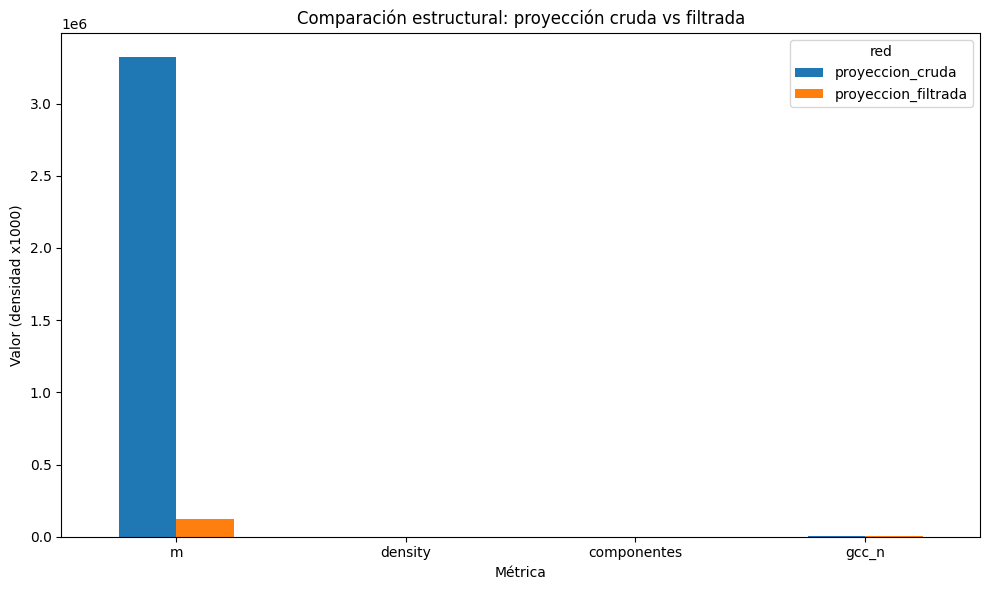

In [8]:

# ============================
# 2.3 Comparación estructural
# ============================

comparacion = pd.DataFrame([
    {"red": "proyeccion_cruda", **resumen_red(G_raw)},
    {"red": "proyeccion_filtrada", **resumen_red(Gf)},
])

display(comparacion.round(4))

plot_df = comparacion.set_index("red")[["m", "density", "componentes", "gcc_n"]].copy()
plot_df["density"] = plot_df["density"] * 1000

fig, ax = plt.subplots(figsize=(10, 6))
plot_df.T.plot(kind="bar", ax=ax)
ax.set_title("Comparación estructural: proyección cruda vs filtrada")
ax.set_ylabel("Valor (densidad x1000)")
ax.set_xlabel("Métrica")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Lectura del gráfico: proyección cruda vs filtrada

El gráfico compara métricas clave entre ambas redes: número de enlaces (m), densidad, número de componentes y tamaño de la componente gigante.

Tres observaciones son centrales:

1. **Colapso del número de enlaces**
   La proyección cruda contiene más de 3 millones de enlaces, mientras que la filtrada reduce esto a ~120 mil. Esta caída no es marginal: indica que la mayoría de los enlaces originales son débiles o triviales.

2. **Reducción de densidad**
   La densidad cae en un orden de magnitud, lo que implica que la red deja de ser casi completamente conectada y pasa a tener estructura más interpretable.

3. **Aparición de múltiples componentes**
   Mientras la red cruda es esencialmente una única componente gigante, la red filtrada presenta varias componentes. Esto es esperable cuando se eliminan enlaces débiles: aparecen subconjuntos más cohesionados.

En conjunto, el gráfico muestra que el filtrado no “degrada” la red, sino que **la hace analíticamente útil**.

### Interpretación de la red analítica

El filtrado reduce drásticamente la conectividad aparente. Eso no debe leerse como una pérdida de información, sino como evidencia de que la proyección cruda estaba inflando vínculos débiles o triviales.

La red que queda no demuestra alianza, coordinación ni conducta estratégica.  
Lo que sí permite afirmar es algo más acotado y sólido: ciertos proveedores presentan patrones de coincidencia suficientemente consistentes como para sobrevivir a un criterio explícito de similitud.

La comparación entre la proyección cruda y la proyección filtrada revela una diferencia estructural sustantiva.

La red cruda presenta una densidad artificialmente alta y una conectividad prácticamente total (una sola componente), lo que es consistente con el efecto conocido de las proyecciones bipartitas: la generación mecánica de enlaces a partir de nodos de alto grado. En este caso, organismos con muchos proveedores inducen co-ocurrencias masivas que no necesariamente reflejan relaciones estructurales relevantes.

En contraste, la red filtrada reduce el número de enlaces en varios órdenes de magnitud (de millones a cientos de miles) y fragmenta parcialmente la estructura (incremento en el número de componentes). Este resultado no implica pérdida de información, sino eliminación de ruido.

El punto clave es el siguiente:

> La proyección cruda no describe estructura; describe combinatoria.

La red filtrada, en cambio, conserva únicamente aquellas relaciones que cumplen simultáneamente:
- un mínimo de co-ocurrencias (shared neighbors), y  
- una similitud relativa (Jaccard) suficientemente alta.

Esto permite interpretar los enlaces restantes como **patrones de coincidencia consistentes**, no como efectos triviales de escala.

Por tanto, la red analítica utilizada en adelante (Gf) no busca capturar toda la interacción posible, sino aquella que sobrevive a un criterio explícito de relevancia estructural.

---

# 3. Centralidades y métricas nodales

## Estrategia

Las métricas se calculan sobre la **red filtrada** y, cuando dependen de caminos, sobre su **componente gigante**.  
Además, para evitar cuellos de botella innecesarios, `betweenness` se calcula en versión aproximada cuando la red es grande.

Esto no debilita el análisis. Al contrario: hace explícito que la medición debe ser proporcional al tamaño del grafo.


In [9]:

# ============================
# 3.1 Selección de componente principal
# ============================

if Gf.number_of_edges() > 0:
    gcc_nodes = max(nx.connected_components(Gf), key=len)
    G_main = Gf.subgraph(gcc_nodes).copy()
else:
    G_main = Gf.copy()

print("Red usada para centralidades (componente principal filtrada)")
print("Nodos:", G_main.number_of_nodes())
print("Enlaces:", G_main.number_of_edges())


Red usada para centralidades (componente principal filtrada)
Nodos: 4238
Enlaces: 121470


In [10]:

# ============================
# 3.2 Centralidades
# ============================

degree_c = nx.degree_centrality(G_main)
strength = dict(G_main.degree(weight="weight"))
closeness_c = nx.closeness_centrality(G_main) if G_main.number_of_nodes() > 1 else {}

# Betweenness aproximada si el grafo es grande
if G_main.number_of_nodes() > 1500:
    k_bt = min(200, G_main.number_of_nodes())
    betweenness_c = nx.betweenness_centrality(
        G_main, k=k_bt, normalized=True, weight=None, seed=RANDOM_SEED
    )
else:
    betweenness_c = nx.betweenness_centrality(G_main, normalized=True, weight=None)

try:
    eigenvector_c = nx.eigenvector_centrality(G_main, max_iter=2000, weight="weight")
except Exception:
    eigenvector_c = {n: np.nan for n in G_main.nodes()}

try:
    pagerank_c = nx.pagerank(G_main, weight="weight")
except Exception:
    pagerank_c = {n: np.nan for n in G_main.nodes()}

local_clustering = nx.clustering(G_main, weight=None)

print("Centralidades calculadas correctamente.")


Centralidades calculadas correctamente.


---

# 4. Feature store nodal

Aquí la red deja de ser solamente una estructura para visualizar y pasa a ser un **generador de variables**.  
La lógica es simple:

- cada nodo proveedor recibe un vector de atributos estructurales;
- esas variables se pueden comparar, rankear, exportar y reutilizar.

Eso transforma la red en un pequeño **feature store**.


## Interpretación del feature store

El feature store transforma la red en un conjunto de variables estructurales por nodo. Esto permite pasar de una lógica descriptiva a una lógica analítica.

Las métricas capturan dimensiones distintas:

- **Degree centrality / strength**: capturan volumen de conexiones.
- **Betweenness**: identifica nodos que actúan como puentes entre zonas de la red.
- **Closeness**: mide accesibilidad estructural.
- **Eigenvector / PageRank**: capturan centralidad en términos de vecindad influyente.
- **Clustering local**: mide cohesión local.

El ranking de consenso combina estas dimensiones, evitando depender de una sola métrica.

Un hallazgo relevante es que distintos proveedores aparecen destacados según la métrica utilizada:
- algunos dominan en volumen (degree),
- otros en intermediación (betweenness),
- otros en posición estratégica (eigenvector).

Esto confirma que la centralidad no es un concepto único, sino multidimensional.

In [11]:

# ============================
# 4.1 Construcción del feature store
# ============================

feature_store = pd.DataFrame({
    "node": list(G_main.nodes()),
    "degree_centrality": pd.Series(degree_c),
    "betweenness": pd.Series(betweenness_c),
    "closeness": pd.Series(closeness_c),
    "eigenvector": pd.Series(eigenvector_c),
    "pagerank": pd.Series(pagerank_c),
    "strength": pd.Series(strength),
    "clustering_local": pd.Series(local_clustering),
}).reset_index(drop=True)

metric_core = [
    "degree_centrality", "betweenness", "closeness",
    "eigenvector", "pagerank", "strength"
]

for col in metric_core:
    feature_store[f"rank_{col}"] = feature_store[col].rank(ascending=False, method="min")
    sd = feature_store[col].std(ddof=0)
    feature_store[f"z_{col}"] = ((feature_store[col] - feature_store[col].mean()) / sd) if sd > 0 else 0.0
    feature_store[f"top5pct_{col}"] = (
        feature_store[col] >= feature_store[col].quantile(0.95)
    ).astype(int)

feature_store["mean_rank_core"] = feature_store[[f"rank_{c}" for c in metric_core[:-1]]].mean(axis=1)
feature_store["rank_consenso"] = feature_store["mean_rank_core"].rank(method="min")

feature_store = feature_store.sort_values("rank_consenso").reset_index(drop=True)

display(feature_store.head(15))
print("Shape feature store:", feature_store.shape)


,node,degree_centrality,betweenness,closeness,eigenvector,pagerank,strength,clustering_local,rank_degree_centrality,z_degree_centrality,top5pct_degree_centrality,rank_betweenness,z_betweenness,top5pct_betweenness,rank_closeness,z_closeness,top5pct_closeness,rank_eigenvector,z_eigenvector,top5pct_eigenvector,rank_pagerank,z_pagerank,top5pct_pagerank,rank_strength,z_strength,top5pct_strength,mean_rank_core,rank_consenso
0,Comercial Occidente Ltda,0.099363,0.005906,0.430240,0.024447,0.001706,7433.0,0.341726,2.0,3.766362,1,75.0,3.741281,1,1.0,2.697690,1,234.0,1.388076,0,57.0,3.963418,1,193.0,2.013435,1,73.8,1.0
1,"""FACAVA"" Electricidad",0.090158,0.004309,0.419049,0.032820,0.001967,9342.0,0.391571,23.0,3.362464,1,129.0,2.626893,1,8.0,2.451829,1,182.0,1.950466,1,42.0,4.665050,1,150.0,2.609865,1,76.8,2.0
2,ALEJANDRO EGAS,0.092754,0.004176,0.425231,0.017407,0.001741,6132.0,0.301786,10.0,3.476384,1,137.0,2.534144,1,2.0,2.587649,1,283.0,0.915249,0,55.0,4.055870,1,223.0,1.606962,0,97.4,3.0
3,NUEVO HORIZONTE LIMITADA,0.084022,0.003190,0.413810,0.037511,0.001896,9943.0,0.428834,93.0,3.093198,1,196.0,1.845614,1,18.0,2.336739,1,162.0,2.265534,1,46.0,4.476046,1,135.0,2.797636,1,103.0,4.0
4,Sociedad Tecnológica y Servicios Express Ltda,0.084494,0.002225,0.412963,0.041665,0.002223,11276.0,0.420215,85.0,3.113911,1,304.0,1.172855,0,20.0,2.318132,1,143.0,2.544528,1,25.0,5.357475,1,108.0,3.214107,1,115.4,5.0
5,"Estalista, Materiales Educativos",0.084258,0.002618,0.414660,0.028035,0.001779,8135.0,0.390001,88.0,3.103554,1,250.0,1.446799,0,17.0,2.355423,1,207.0,1.629097,1,53.0,4.160684,1,172.0,2.232761,1,123.0,6.0
6,resein chile,0.099127,0.001847,0.393956,0.053869,0.001545,13076.0,0.533902,3.0,3.756006,1,364.0,0.908986,0,107.0,1.900567,1,92.0,3.364211,1,75.0,3.529491,1,76.0,3.776482,1,128.2,7.0
7,CENTRO FERRETERO PULMAHUE LTDA,0.099835,0.007708,0.407208,0.001243,0.001667,3050.0,0.195545,1.0,3.787075,1,35.0,4.998127,1,28.0,2.191700,1,534.0,-0.170385,0,62.0,3.856358,1,349.0,0.644050,0,132.0,8.0
8,Avalco SpA,0.081662,0.004542,0.420212,0.014363,0.001317,4944.0,0.333769,122.0,2.989634,1,123.0,2.789243,1,7.0,2.477394,1,308.0,0.710799,0,114.0,2.914030,1,260.0,1.235795,0,134.8,9.0
9,Juana del Carmen,0.087562,0.006041,0.420755,0.002717,0.001383,3456.0,0.267939,53.0,3.248543,1,70.0,3.835293,1,5.0,2.489312,1,453.0,-0.071378,0,98.0,3.092736,1,316.0,0.770897,0,135.8,10.0


Shape feature store: (4238, 28)


In [12]:

# ============================
# 4.2 Exportación y top rankings
# ============================

feature_store.to_csv("feature_store_tarea2_optimizado.csv", index=False)

top10_degree = feature_store[["node", "degree_centrality", "rank_degree_centrality"]].sort_values(
    "degree_centrality", ascending=False
).head(10)

top10_betweenness = feature_store[["node", "betweenness", "rank_betweenness"]].sort_values(
    "betweenness", ascending=False
).head(10)

top10_eigen = feature_store[["node", "eigenvector", "rank_eigenvector"]].sort_values(
    "eigenvector", ascending=False
).head(10)

top10_consenso = feature_store[["node", "mean_rank_core", "rank_consenso"]].sort_values(
    "rank_consenso"
).head(10)

print("Top 10 degree")
display(top10_degree)
print("Top 10 betweenness")
display(top10_betweenness)
print("Top 10 eigenvector")
display(top10_eigen)
print("Top 10 consenso")
display(top10_consenso)

top10_consenso.to_csv("top10_consenso_tarea2_optimizado.csv", index=False)


Top 10 degree


,node,degree_centrality,rank_degree_centrality
7,CENTRO FERRETERO PULMAHUE LTDA,0.099835,1.0
0,Comercial Occidente Ltda,0.099363,2.0
6,resein chile,0.099127,3.0
218,Medtronic Chile SpA,0.094878,4.0
205,Caissa S.A.,0.094406,5.0
200,BIOMET CHILE S A,0.094406,5.0
188,Mediplex,0.094170,7.0
157,ALCON LABORATORIOS CHILE LTDA,0.093462,8.0
120,Importadora y Exportadora CAMIR SPA,0.093226,9.0
2,ALEJANDRO EGAS,0.092754,10.0


Top 10 betweenness


,node,betweenness,rank_betweenness
221,LA VALENCIANA - PUYEHUE,0.017378,1.0
392,papeles y cartones,0.016832,2.0
213,SERVICIOS HIMCE LIMITADA,0.016341,3.0
167,Cerro Name,0.015542,4.0
880,CRR,0.014474,5.0
56,LA CASA DEL DEPORTE,0.014381,6.0
31,COLORMAR SPA,0.014012,7.0
256,Antus Industrial,0.012719,8.0
644,IMAKOY,0.012263,9.0
84,LOPZ,0.012242,10.0


Top 10 eigenvector


,node,eigenvector,rank_eigenvector
408,ETHON PHARMACEUTICALS SPA.,0.145485,1.0
338,WINPHARM,0.142938,2.0
352,DROGUERIA GLOBAL PHARMA SPA,0.142312,3.0
301,OPKO CHILE S.A.,0.141254,4.0
452,Caribean Pharma Ltda,0.140982,5.0
342,LABORATORIOS RECALCINE S.A,0.139809,6.0
397,INVERSIONES PHARMAVISAN S.A.,0.131814,7.0
307,LABORATORIOS ANDROMACO S.A.,0.127212,8.0
249,INMED DROGUERIA LTDA.,0.124435,9.0
281,Awad Artículos Médicos,0.123363,10.0


Top 10 consenso


,node,mean_rank_core,rank_consenso
0,Comercial Occidente Ltda,73.8,1.0
1,"""FACAVA"" Electricidad",76.8,2.0
2,ALEJANDRO EGAS,97.4,3.0
3,NUEVO HORIZONTE LIMITADA,103.0,4.0
4,Sociedad Tecnológica y Servicios Express Ltda,115.4,5.0
5,"Estalista, Materiales Educativos",123.0,6.0
6,resein chile,128.2,7.0
7,CENTRO FERRETERO PULMAHUE LTDA,132.0,8.0
8,Avalco SpA,134.8,9.0
9,Juana del Carmen,135.8,10.0


,degree_centrality,betweenness,closeness,eigenvector,pagerank,strength,clustering_local
degree_centrality,1.000,0.389,0.712,0.680,0.852,0.761,0.099
betweenness,0.389,1.000,0.470,0.014,0.425,0.077,-0.177
closeness,0.712,0.470,1.000,0.351,0.626,0.420,0.100
eigenvector,0.680,0.014,0.351,1.000,0.835,0.991,0.141
pagerank,0.852,0.425,0.626,0.835,1.000,0.882,0.027
strength,0.761,0.077,0.420,0.991,0.882,1.000,0.135
clustering_local,0.099,-0.177,0.100,0.141,0.027,0.135,1.000


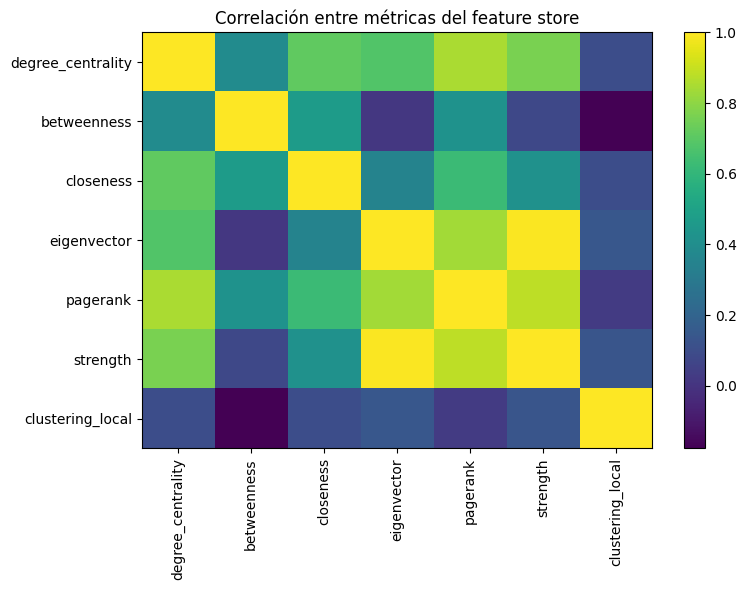

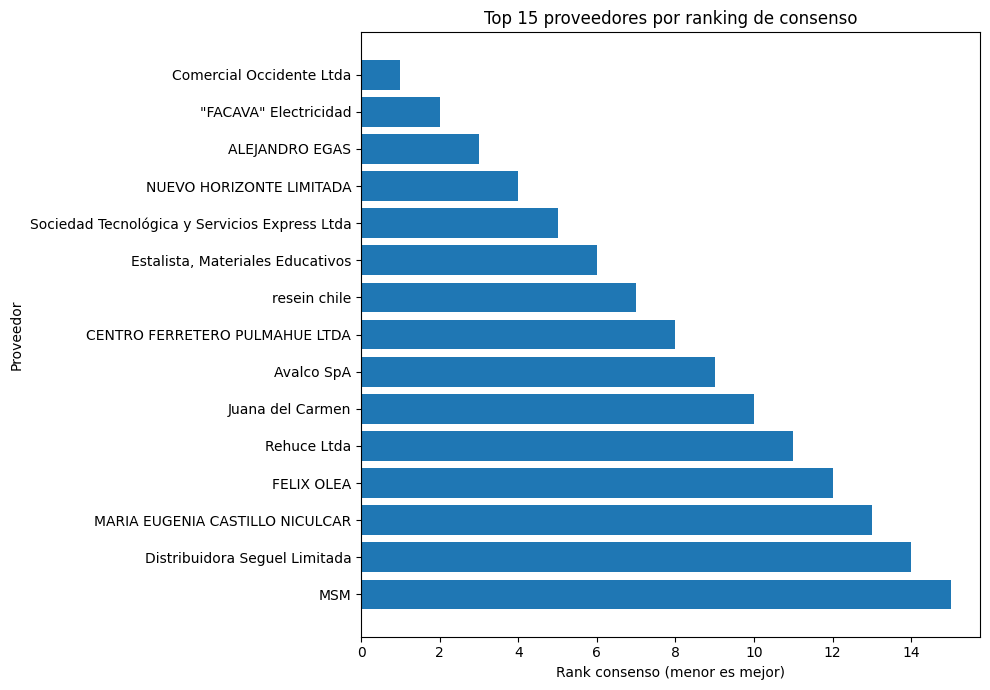

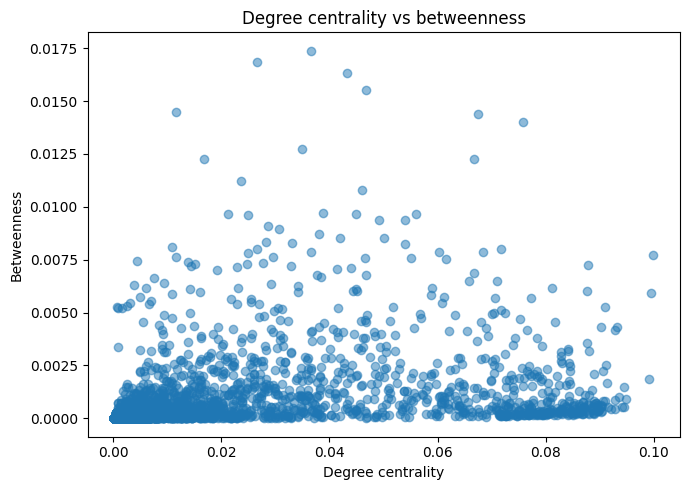

In [13]:

# ============================
# 4.3 Correlaciones y visualizaciones
# ============================

metric_cols = [
    "degree_centrality", "betweenness", "closeness",
    "eigenvector", "pagerank", "strength", "clustering_local"
]

corr = feature_store[metric_cols].corr(numeric_only=True)
display(corr.round(3))

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Correlación entre métricas del feature store")
plt.tight_layout()
plt.show()

top_plot = feature_store.sort_values("rank_consenso").head(15).sort_values("rank_consenso", ascending=False)
plt.figure(figsize=(10, 7))
plt.barh(top_plot["node"], top_plot["rank_consenso"])
plt.title("Top 15 proveedores por ranking de consenso")
plt.xlabel("Rank consenso (menor es mejor)")
plt.ylabel("Proveedor")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(feature_store["degree_centrality"], feature_store["betweenness"], alpha=0.5)
plt.title("Degree centrality vs betweenness")
plt.xlabel("Degree centrality")
plt.ylabel("Betweenness")
plt.tight_layout()
plt.show()


In [ ]:

# ============================
# 4.1.b Variable contextual y chequeos de consistencia
# ============================

grado_bip = {n: B.degree(n) for n in G_main.nodes()}
feature_store["grado_bip"] = feature_store["node"].map(grado_bip)

print("Resumen rápido de grado bipartito en la red analítica")
display(feature_store[["grado_bip"]].describe().round(3))


In [ ]:

# ============================
# 4.2.b Movilidad de rankings entre métricas
# ============================

top_k = 20
top_degree_set = set(feature_store.nsmallest(top_k, "rank_degree_centrality")["node"])
top_bet_set = set(feature_store.nsmallest(top_k, "rank_betweenness")["node"])
top_pr_set = set(feature_store.nsmallest(top_k, "rank_pagerank")["node"])

overlap_rows = pd.DataFrame([
    {"comparacion": f"top{top_k} degree ∩ betweenness", "n_comun": len(top_degree_set & top_bet_set)},
    {"comparacion": f"top{top_k} degree ∩ pagerank", "n_comun": len(top_degree_set & top_pr_set)},
    {"comparacion": f"top{top_k} betweenness ∩ pagerank", "n_comun": len(top_bet_set & top_pr_set)},
    {"comparacion": f"top{top_k} en las tres métricas", "n_comun": len(top_degree_set & top_bet_set & top_pr_set)},
])

display(overlap_rows)

triple_overlap = top_degree_set & top_bet_set & top_pr_set
if triple_overlap:
    print("Nodos presentes en el top de las tres métricas")
    display(
        feature_store.loc[feature_store["node"].isin(triple_overlap),
                          ["node", "degree_centrality", "betweenness", "pagerank", "rank_consenso"]]
        .sort_values("rank_consenso")
        .reset_index(drop=True)
    )
else:
    print("No hay intersección completa entre las tres métricas en el top seleccionado.")


In [ ]:

# ============================
# 4.3.b Heatmap anotado con grado bipartito
# ============================

metric_cols_ext = [
    "degree_centrality", "betweenness", "closeness",
    "eigenvector", "pagerank", "strength", "clustering_local", "grado_bip"
]

corr_ext = feature_store[metric_cols_ext].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_ext.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_ext.columns)))
ax.set_yticks(range(len(corr_ext.index)))
ax.set_xticklabels(corr_ext.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_ext.index, fontsize=9)

for i in range(len(corr_ext.index)):
    for j in range(len(corr_ext.columns)):
        ax.text(j, i, f"{corr_ext.values[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.colorbar(im, ax=ax)
ax.set_title("Correlación entre métricas del feature store (incluye grado bipartito)")
plt.tight_layout()
plt.show()

display(corr_ext.round(3))


## Degree vs Betweenness

El scatter plot muestra la relación entre centralidad por grado y betweenness.

Se observa que:

- la mayoría de los nodos tiene bajo betweenness, incluso con grado moderado,
- solo un subconjunto pequeño combina alto grado con alta intermediación.

Esto es consistente con redes donde:
- muchos nodos participan ampliamente (alto grado),
- pero pocos cumplen roles de puente estructural.

Interpretación clave:

> Tener muchas conexiones no implica ser estructuralmente relevante como intermediario.

## Correlación entre métricas

El mapa de calor muestra la relación entre las distintas métricas del feature store.

Se observan tres patrones claros:

1. **Alta correlación entre degree, pagerank y eigenvector**
   Esto sugiere que gran parte de la estructura está dominada por efectos de grado: nodos con muchas conexiones tienden a ser también centrales bajo múltiples definiciones.

2. **Betweenness relativamente independiente**
   Betweenness presenta correlaciones más bajas, lo que indica que captura una dimensión distinta: intermediación estructural, no solo volumen.

3. **Clustering con baja correlación general**
   El clustering local no está fuertemente alineado con otras métricas, lo que refuerza que mide cohesión local más que centralidad global.

Conclusión:

> No todas las métricas aportan información nueva. Algunas redundan; otras revelan estructura distinta.

---

# 5. Sensibilidad a umbrales

La robustez se evalúa sin recalcular toda la proyección desde cero.  
Como ya tenemos el conteo de pares y el Jaccard para cada enlace candidato, basta con reaplicar distintos umbrales sobre esa tabla.

Eso permite probar sensibilidad con un costo marginal muy bajo.


,n,m,density,componentes,aislados,gcc_n,gcc_share,avg_clustering_gcc,avg_path_length_gcc,min_compartidos,min_jaccard,top_degree_node,top_degree_value
0,6452,504360,0.0242,2,0,6450,0.9997,0.5615,NaN,2,0.05,TELEFONIA COMUNICACIONES DATOS - Casa Matriz,0.1972
1,6312,200434,0.0101,3,0,6308,0.9994,0.4224,NaN,2,0.10,INVERDAN,0.0704
2,4268,121487,0.0133,15,0,4238,0.9930,0.4578,NaN,3,0.10,CENTRO FERRETERO PULMAHUE LTDA,0.0998
3,3803,53924,0.0075,39,0,3724,0.9792,0.3846,NaN,3,0.15,Mediplex,0.0736
4,2224,43751,0.0177,29,0,2149,0.9663,0.4529,4.0647,4,0.15,Mediplex,0.1276


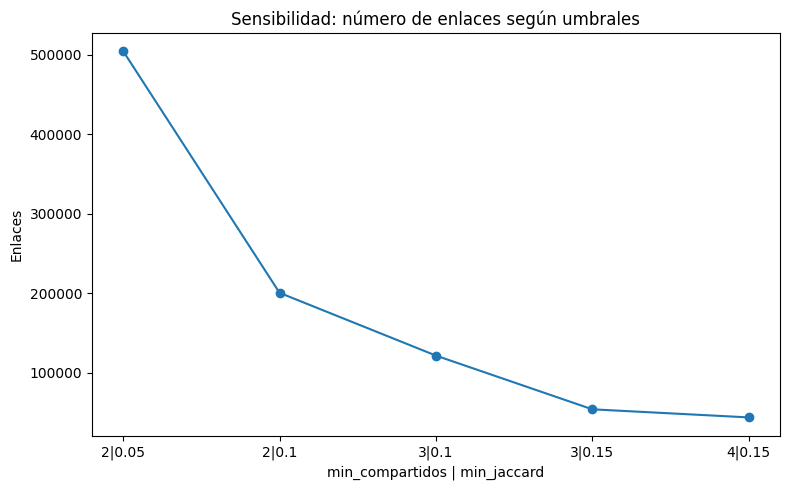

In [14]:

# ============================
# 5. Sensibilidad por umbrales
# ============================

grid_params = [
    (2, 0.05),
    (2, 0.10),
    (3, 0.10),
    (3, 0.15),
    (4, 0.15),
]

resultados_sens = []

for th_comp, th_j in grid_params:
    Gtmp, kept = build_filtered_projection_graph(pair_counts_df, min_shared=th_comp, min_jaccard=th_j)
    r = resumen_red(Gtmp)
    r["min_compartidos"] = th_comp
    r["min_jaccard"] = th_j

    if Gtmp.number_of_edges() > 0:
        gcc = max(nx.connected_components(Gtmp), key=len)
        Gcc = Gtmp.subgraph(gcc).copy()
        deg = nx.degree_centrality(Gcc)
        top_node = max(deg, key=deg.get)
        r["top_degree_node"] = top_node
        r["top_degree_value"] = deg[top_node]
    else:
        r["top_degree_node"] = np.nan
        r["top_degree_value"] = np.nan

    resultados_sens.append(r)

sens_df = pd.DataFrame(resultados_sens)
display(sens_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(range(len(sens_df)), sens_df["m"], marker="o")
plt.xticks(range(len(sens_df)), [f"{a}|{b}" for a, b in zip(sens_df["min_compartidos"], sens_df["min_jaccard"])])
plt.title("Sensibilidad: número de enlaces según umbrales")
plt.xlabel("min_compartidos | min_jaccard")
plt.ylabel("Enlaces")
plt.tight_layout()
plt.show()


## Sensibilidad a umbrales

El análisis de sensibilidad muestra cómo cambia la red al variar:
- el mínimo de co-ocurrencias, y
- el umbral de Jaccard.

El resultado es monotónico:

- al aumentar los umbrales, el número de enlaces disminuye rápidamente,
- la red se vuelve más pequeña y más selectiva.

Esto tiene dos implicancias:

1. La estructura no es fija: depende de decisiones analíticas explícitas.
2. Existe un trade-off entre:
   - cobertura (más enlaces),
   - y calidad estructural (enlaces más fuertes).

El punto elegido (min_shared=3, Jaccard=0.10) equilibra ambos aspectos.

---

# 6. Baselines nulos bipartitos

## Idea

No basta con describir la red observada.  
También conviene preguntar si su estructura proyectada podría surgir de mecanismos más simples.

Aquí comparo la red real con dos nulos:

1. **Bipartito aleatorio del mismo tamaño**  
   mantiene número de nodos y número de enlaces, pero rompe la estructura observada;

2. **Bipartito con randomización por swaps**  
   preserva aproximadamente la secuencia de grados bipartitos y desordena las conexiones.

## Nota práctica

Para que el notebook siga siendo utilizable, reduzco deliberadamente el número de simulaciones. El foco es metodológico, no hacer una gran corrida Monte Carlo.


In [15]:

# ============================
# 6.1 Funciones auxiliares de baseline
# ============================

def random_same_size_bipartite_from_nodes(u_nodes, v_nodes, m, seed=123):
    rng = random.Random(seed)
    chosen = set()

    while len(chosen) < m:
        u = rng.choice(u_nodes)
        v = rng.choice(v_nodes)
        chosen.add((u, v))

    Br = nx.Graph()
    Br.add_nodes_from(u_nodes, bipartite=0, kind="proveedor")
    Br.add_nodes_from(v_nodes, bipartite=1, kind="organismo")
    Br.add_edges_from(chosen)
    return Br


def bipartite_degree_preserving_swap(B, nswap=5000, max_tries=100000, seed=123):
    rng = random.Random(seed)
    G = B.copy()
    edge_list = list(G.edges())

    tries = 0
    swaps = 0

    while swaps < nswap and tries < max_tries and len(edge_list) >= 2:
        tries += 1
        (a, b), (c, d) = rng.sample(edge_list, 2)

        if G.nodes[a]["bipartite"] == 1:
            a, b = b, a
        if G.nodes[c]["bipartite"] == 1:
            c, d = d, c

        if len({a, b, c, d}) < 4:
            continue
        if G.has_edge(a, d) or G.has_edge(c, b):
            continue

        G.remove_edge(a, b)
        G.remove_edge(c, d)
        G.add_edge(a, d)
        G.add_edge(c, b)

        edge_list = list(G.edges())
        swaps += 1

    return G


def projected_summary_from_bipartite(Bb, min_comp=3, min_j=0.10):
    edf = pd.DataFrame(list(Bb.edges()), columns=["src", "dst"])

    # Reordenar columnas según bipartición
    rows = []
    for a, b in Bb.edges():
        if Bb.nodes[a]["bipartite"] == 0:
            rows.append((a, b))
        else:
            rows.append((b, a))
    edf = pd.DataFrame(rows, columns=["proveedor", "organismo"])

    pair_df, prov_deg_tmp, _ = build_pair_counts_from_edges(edf)
    if len(pair_df) == 0:
        Gtmp = nx.Graph()
        return resumen_red(Gtmp)

    pair_df = add_jaccard(pair_df, prov_deg_tmp)
    Gtmp, kept = build_filtered_projection_graph(pair_df, min_shared=min_comp, min_jaccard=min_j)
    return resumen_red(Gtmp)


In [ ]:

# ============================
# 5.b Visualización ampliada de sensibilidad
# ============================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels = [f"{a}|{b}" for a, b in zip(sens_df["min_compartidos"], sens_df["min_jaccard"])]
x = np.arange(len(labels))

axes[0].bar(x, sens_df["m"], alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha="right")
axes[0].set_title("Número de enlaces")
axes[0].set_xlabel("min_shared | min_jaccard")
axes[0].set_ylabel("m")

axes[1].bar(x, sens_df["gcc_share"] * 100, alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30, ha="right")
axes[1].set_title("% de nodos en componente gigante")
axes[1].set_xlabel("min_shared | min_jaccard")
axes[1].set_ylabel("% GCC")

axes[2].bar(x, sens_df["avg_clustering_gcc"].fillna(0), alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=30, ha="right")
axes[2].set_title("Clustering medio del GCC")
axes[2].set_xlabel("min_shared | min_jaccard")
axes[2].set_ylabel("clustering")

plt.suptitle("Sensibilidad estructural frente a cambios de umbral")
plt.tight_layout()
plt.show()


In [ ]:

# ============================
# 6.2 Simulación de baselines
# ============================

N_SIM = 6
baseline_rows = []

real_stats = projected_summary_from_bipartite(B, min_comp=MIN_SHARED, min_j=MIN_JACCARD)
baseline_rows.append({"modelo": "real", "sim": 0, **real_stats})

for s in range(N_SIM):
    Br = random_same_size_bipartite_from_nodes(u_nodes, v_nodes, B.number_of_edges(), seed=100 + s)
    stats = projected_summary_from_bipartite(Br, min_comp=MIN_SHARED, min_j=MIN_JACCARD)
    baseline_rows.append({"modelo": "bipartito_random_mismo_tamano", "sim": s + 1, **stats})

for s in range(N_SIM):
    Bd = bipartite_degree_preserving_swap(
        B,
        nswap=min(5 * B.number_of_edges(), 10000),
        max_tries=50000,
        seed=200 + s
    )
    stats = projected_summary_from_bipartite(Bd, min_comp=MIN_SHARED, min_j=MIN_JACCARD)
    baseline_rows.append({"modelo": "bipartito_degree_preserving", "sim": s + 1, **stats})

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv("baseline_summary_tarea2_optimizado.csv", index=False)

display(baseline_df.head())
print("Resumen de simulaciones por modelo")
display(baseline_df["modelo"].value_counts())


In [ ]:

# ============================
# 6.3 Comparación real vs nulos
# ============================

metricas_baseline = ["m", "density", "gcc_share", "avg_clustering_gcc", "avg_path_length_gcc"]

summary_baselines = baseline_df.groupby("modelo")[metricas_baseline].agg(["mean", "std", "min", "max"])
display(summary_baselines)

real_row = baseline_df[baseline_df["modelo"] == "real"].iloc[0]
z_rows = []

for modelo in ["bipartito_random_mismo_tamano", "bipartito_degree_preserving"]:
    sub = baseline_df[baseline_df["modelo"] == modelo]
    row = {"baseline": modelo}
    for m in metricas_baseline:
        mu = sub[m].mean()
        sd = sub[m].std(ddof=0)
        row[f"real_{m}"] = real_row[m]
        row[f"mean_{m}"] = mu
        row[f"z_{m}"] = (real_row[m] - mu) / sd if sd and not np.isnan(sd) else np.nan
    z_rows.append(row)

z_df = pd.DataFrame(z_rows)
display(z_df.round(3))


m                              \
                                        mean         std     min     max   
modelo                                                                     
bipartito_degree_preserving     81146.666667  476.249374   80718   81993   
bipartito_random_mismo_tamano   15533.833333   81.477400   15437   15635   
real                           121484.000000         NaN  121484  121484   

                                density                                \
                                   mean       std       min       max   
modelo                                                                  
bipartito_degree_preserving    0.012718  0.000289  0.012224  0.012996   
bipartito_random_mismo_tamano  0.000853  0.000010  0.000844  0.000866   
real                           0.013354       NaN  0.013354  0.013354   

                              gcc_share                                \
                                   mean       std       min       max   
modelo                                                                  
bipartito_degree_preserving    0.992443  0.001182  0.990725  0.994380   
bipartito_random_mismo_tamano  0.996384  0.001013  0.994396  0.997172   
real                           0.992968       NaN  0.992968  0.992968   

                              avg_clustering_gcc                      \
                                            mean       std       min   
modelo                                                                 
bipartito_degree_preserving             0.314652  0.006223  0.308435   
bipartito_random_mismo_tamano           0.023458  0.001714  0.020630   
real                                    0.457973       NaN  0.457973   

                                        avg_path_length_gcc              
                                    max                mean std min max  
modelo                                                                   
bipartito_degree_preserving    0.325222                 NaN NaN NaN NaN  
bipartito_random_mismo_tamano  0.025824                 NaN NaN NaN NaN  
real                           0.457973                 NaN NaN NaN NaN

,baseline,real_m,mean_m,z_m,real_density,mean_density,z_density,real_gcc_share,mean_gcc_share,z_gcc_share,real_avg_clustering_gcc,mean_avg_clustering_gcc,z_avg_clustering_gcc,real_avg_path_length_gcc,mean_avg_path_length_gcc,z_avg_path_length_gcc
0,bipartito_random_mismo_tamano,121484,15533.833,1424.476,0.013,0.001,1428.309,0.993,0.996,-3.696,0.458,0.023,277.687,NaN,NaN,NaN
1,bipartito_degree_preserving,121484,81146.667,92.782,0.013,0.013,2.412,0.993,0.992,0.486,0.458,0.315,25.231,NaN,NaN,NaN


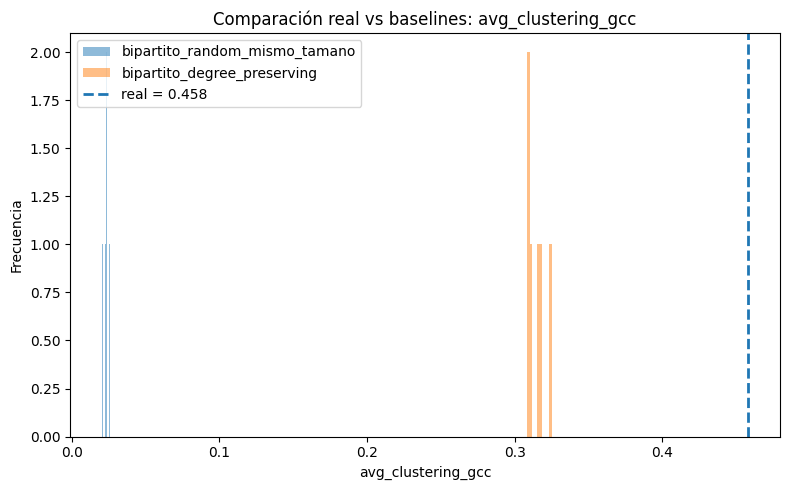

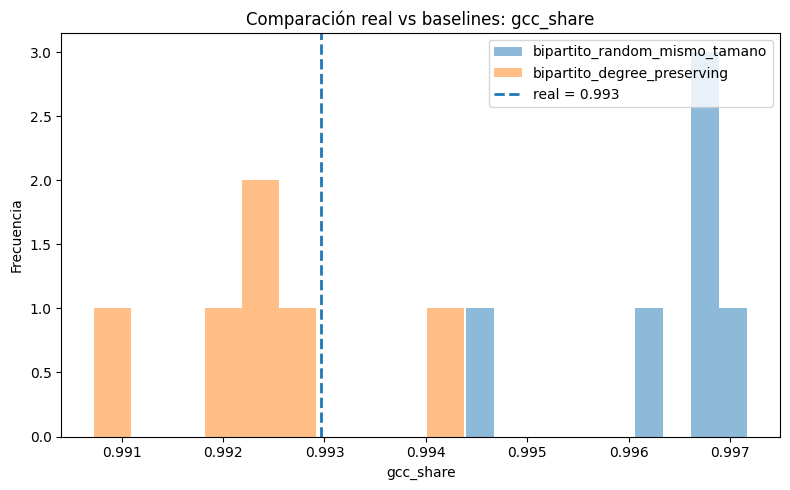

In [ ]:

# ============================
# 6.4 Visualización real vs baselines
# ============================

for metric in ["avg_clustering_gcc", "gcc_share"]:
    plt.figure(figsize=(8,5))
    for modelo in baseline_df["modelo"].unique():
        vals = baseline_df.loc[baseline_df["modelo"] == modelo, metric].dropna().values
        if modelo != "real":
            plt.hist(vals, bins=10, alpha=0.5, label=modelo)

    real_val = baseline_df.loc[baseline_df["modelo"] == "real", metric].iloc[0]
    plt.axvline(real_val, linestyle="--", linewidth=2, label=f"real = {real_val:.3f}")
    plt.title(f"Comparación real vs baselines: {metric}")
    plt.xlabel(metric)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Comparación con baselines nulos

La red observada se compara con dos modelos nulos:

1. Bipartito aleatorio (mismo tamaño)
2. Bipartito con preservación de grado (degree-preserving)

Los resultados muestran diferencias claras:

- El baseline aleatorio genera redes extremadamente dispersas.
- El baseline con preservación de grado se acerca más, pero sigue siendo distinto.

Particularmente:

- El clustering en la red real es significativamente mayor.
- La estructura no puede explicarse solo por el tamaño o la distribución de grados.

Esto sugiere que:

> Existe señal estructural que no emerge de mecanismos aleatorios simples.

Sin embargo, esta señal debe interpretarse con cautela:
no implica coordinación ni causalidad, solo estructura no trivial.

In [ ]:

# ============================
# 6.3.b Lectura compacta de z-scores
# ============================

z_long = []
for _, row in z_df.iterrows():
    baseline = row["baseline"]
    for metric in ["m", "density", "gcc_share", "avg_clustering_gcc", "avg_path_length_gcc"]:
        z_long.append({
            "baseline": baseline,
            "metrica": metric,
            "z_score": row.get(f"z_{metric}", np.nan)
        })

z_long_df = pd.DataFrame(z_long)
display(z_long_df.pivot(index="metrica", columns="baseline", values="z_score").round(3))

print("|z| > 1.96 sugiere una diferencia marcada respecto del baseline.")


---

# 7. Hallazgos y memo final

## Hallazgos principales

1. **La proyección cruda sobredimensiona la conectividad**
   La mayoría de los enlaces desaparece al aplicar criterios mínimos de relevancia. Esto confirma que la proyección sin filtrado induce ruido estructural significativo.

2. **La red filtrada conserva señal interpretable**
   Persisten patrones de coincidencia consistentes entre proveedores, lo que permite trabajar con una estructura más estable y defendible.

3. **La heterogeneidad de grado domina gran parte de la estructura**
   Muchas métricas están fuertemente correlacionadas, lo que indica que el grado explica una fracción importante de la organización de la red.

4. **Existen dimensiones estructurales adicionales**
   Métricas como betweenness capturan roles distintos, mostrando que no toda la centralidad es reducible al grado.

5. **La red observada se separa de los modelos nulos**
   Esto sugiere que la estructura no es completamente explicable por aleatoriedad ni por la sola distribución de grados.

---

## Limitaciones

- El análisis se basa en una única ventana temporal.
- La ausencia de un enlace no implica imposibilidad real.
- El filtrado introduce decisiones analíticas que afectan los resultados.
- Las métricas capturan estructura, no comportamiento ni causalidad.

---

## Cierre

El punto central no es la red proyectada, sino el proceso:

> La bipartita es el objeto primario; la proyección es una transformación que debe controlarse.

La optimización implementada no solo mejora el rendimiento computacional, sino que alinea el procedimiento con principios metodológicos clave de la ciencia de redes:

- evitar inferencias basadas en artefactos de construcción,
- explicitar supuestos,
- y contrastar contra modelos nulos.

En este sentido, el valor del análisis no está en “mapear relaciones”, sino en **delimitar cuidadosamente qué parte de la estructura es interpretable**.

In [ ]:

# ============================
# 8. Artefactos exportados
# ============================

print("Archivos exportados por este notebook:")
for fname in [
    "feature_store_tarea2_optimizado.csv",
    "top10_consenso_tarea2_optimizado.csv",
    "baseline_summary_tarea2_optimizado.csv",
]:
    print("-", fname, "->", "OK" if Path(fname).exists() else "no generado aún")


Archivos exportados por este notebook:
- feature_store_tarea2_optimizado.csv -> OK
- top10_consenso_tarea2_optimizado.csv -> OK
- baseline_summary_tarea2_optimizado.csv -> OK
